In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [191]:
df = pd.read_csv('C:/Users/nitin/OneDrive/Desktop/Data Analyst/Data/Sample_Superstore.csv',sep=',',encoding='cp1252')

In [192]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [193]:
summary = pd.DataFrame({
    'dtype' : df.dtypes,
    'missing' : df.isna().sum(),
    'missing_%': df.isna().mean()*100,
    'unique' : df.nunique()
})
summary

,dtype,missing,missing_%,unique
Row ID,int64,0,0.0,9994
Order ID,object,0,0.0,5009
Order Date,object,0,0.0,1237
Ship Date,object,0,0.0,1334
Ship Mode,object,0,0.0,4
Customer ID,object,0,0.0,793
Customer Name,object,0,0.0,793
Segment,object,0,0.0,3
Country,object,0,0.0,1
City,object,0,0.0,531


In [194]:
df_numeric = df.select_dtypes('number')


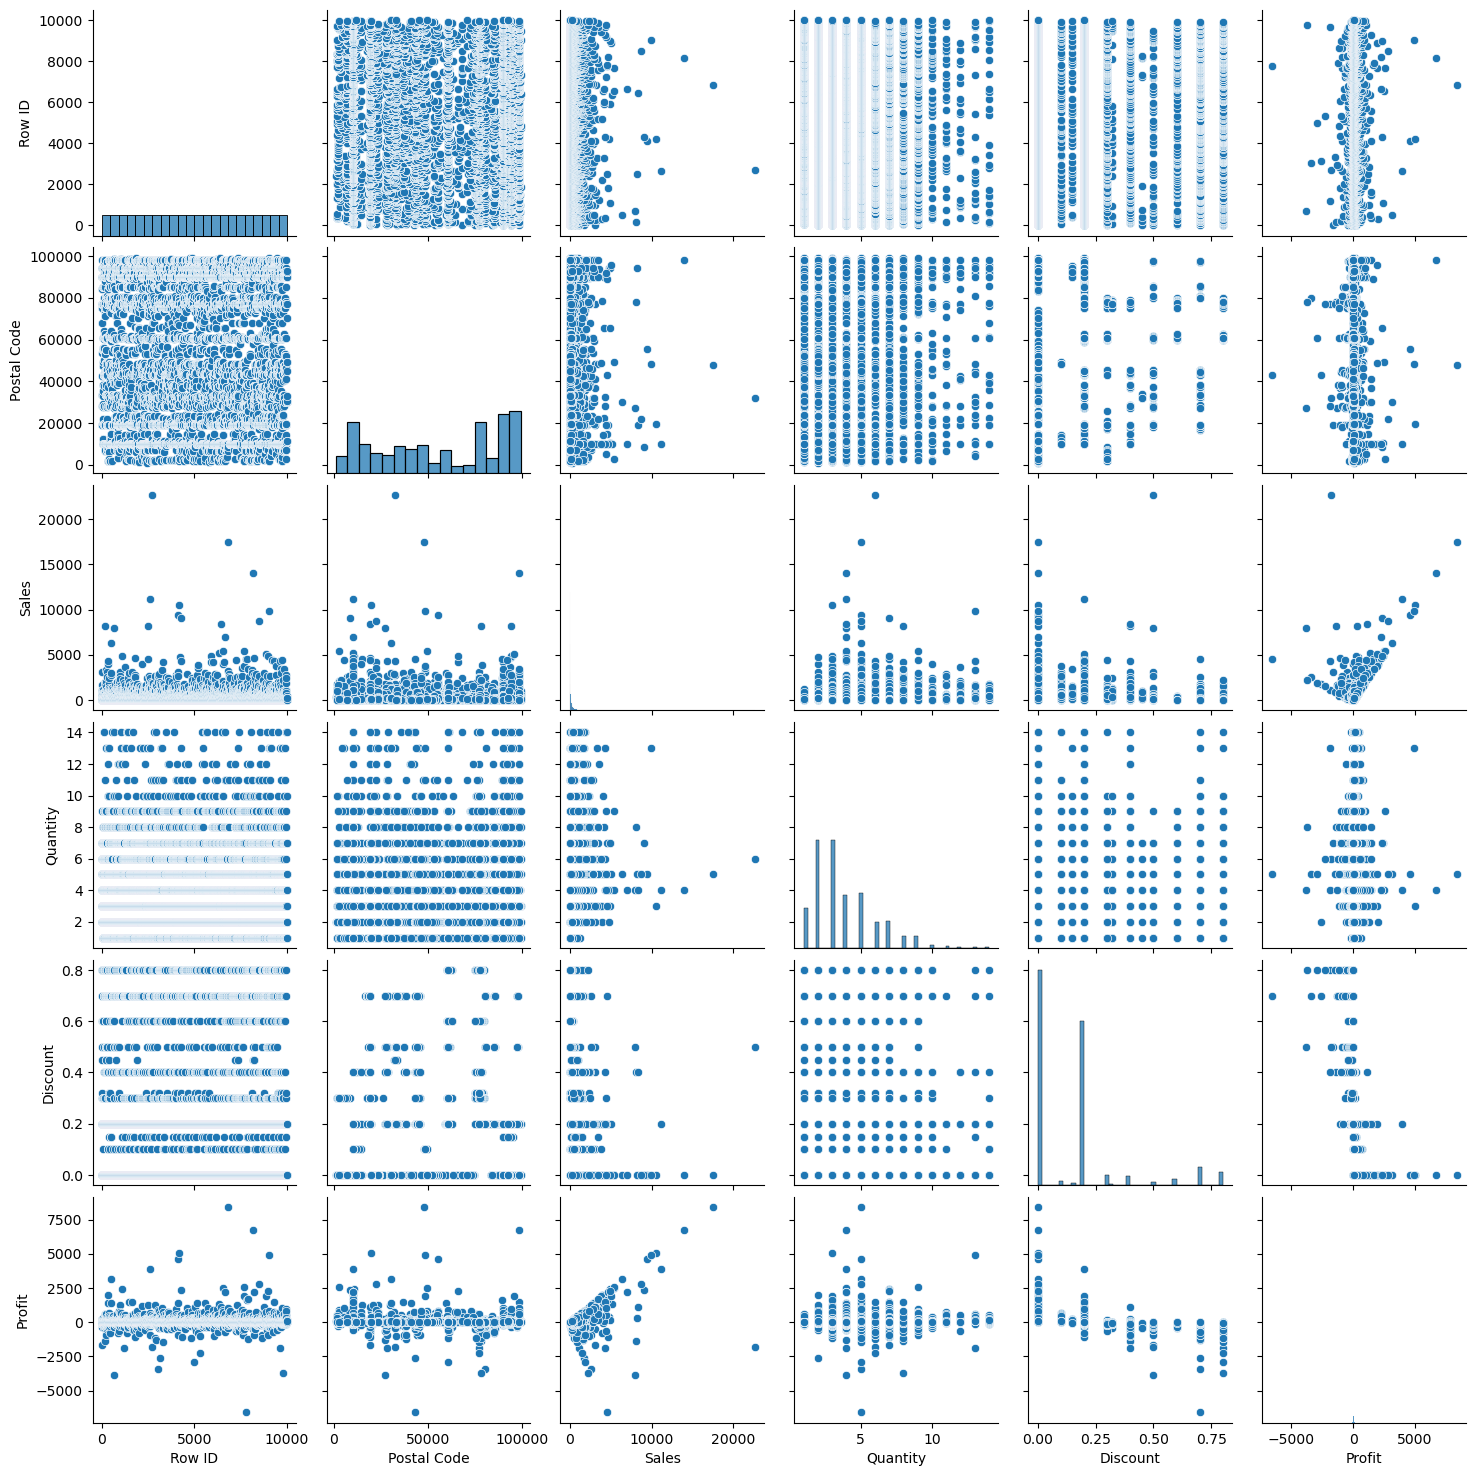

In [195]:
sns.pairplot(df_numeric)

In [196]:
correlation = (df_numeric.corr()).round(2)
filtered = correlation[correlation >0.3 ]

<Axes: >

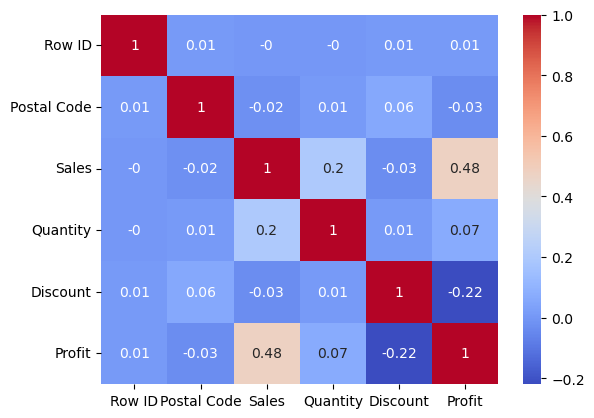

In [197]:
sns.heatmap(correlation,cmap='coolwarm',annot=True)

In [198]:
# State wise analysis

state_chart = df.groupby('State').agg(
    revenue = ('Sales','sum'),
    Quantity = ('Quantity','sum'),
    profit = ('Profit','sum'),
    AOV = ('Sales','mean'))
state_chart['revenue_%'] =(state_chart['revenue']/state_chart['revenue'].sum() *100 ).round(2)
state_chart

,revenue,Quantity,profit,AOV,revenue_%
State,,,,,
Alabama,19510.6400,256,5786.8253,319.846557,0.85
Arizona,35282.0010,862,-3427.9246,157.508933,1.54
Arkansas,11678.1300,240,4008.6871,194.635500,0.51
California,457687.6315,7667,76381.3871,228.729451,19.92
Colorado,32108.1180,693,-6527.8579,176.418231,1.40
Connecticut,13384.3570,281,3511.4918,163.223866,0.58
Delaware,27451.0690,367,9977.3748,285.948635,1.19
District of Columbia,2865.0200,40,1059.5893,286.502000,0.12
Florida,89473.7080,1379,-3399.3017,233.612815,3.89


In [199]:
# print(df['Category'].nunique())
category_chart = df.groupby('Category').agg(
    revenue = ('Sales','sum'),
        Quantity = ('Quantity','sum'),
        profit = ('Profit','sum'),
        AOV = ('Sales','mean')
)
category_chart['Revenue_%'] = (category_chart['revenue']/category_chart['revenue'].sum() *100 ).round(2)
category_chart

,revenue,Quantity,profit,AOV,Revenue_%
Category,,,,,
Furniture,741999.7953,8028,18451.2728,349.834887,32.3
Office Supplies,719047.0320,22906,122490.8008,119.324101,31.3
Technology,836154.0330,6939,145454.9481,452.709276,36.4


In [200]:
Sub_Category_chart = df.groupby(['Category','Sub-Category']).agg(
    revenue = ('Sales','sum'),
    Quantity = ('Quantity','sum'),
    profit = ('Profit','sum'),
    AOV = ('Sales','mean')
)
Sub_Category_chart['revenue%'] = (Sub_Category_chart['revenue']/Sub_Category_chart['revenue'].sum() *100 ).round(2)

Sub_Category_chart

revenue  Quantity      profit          AOV  \
Category        Sub-Category                                                   
Furniture       Bookcases     114879.9963       868  -3472.5560   503.859633   
                Chairs        328449.1030      2356  26590.1663   532.332420   
                Furnishings    91705.1640      3563  13059.1436    95.825668   
                Tables        206965.5320      1241 -17725.4811   648.794771   
Office Supplies Appliances    107532.1610      1729  18138.0054   230.755710   
                Art            27118.7920      3000   6527.7870    34.068834   
                Binders       203412.7330      5974  30221.7633   133.560560   
                Envelopes      16476.4020       906   6964.1767    64.867724   
                Fasteners       3024.2800       914    949.5182    13.936774   
                Labels         12486.3120      1400   5546.2540    34.303055   
                Paper          78479.2060      5178  34053.5693    57.284092   
                Storage       223843.6080      3158  21278.8264   264.590553   
                Supplies       46673.5380       647  -1189.0995   245.650200   
Technology      Accessories   167380.3180      2976  41936.6357   215.974604   
                Copiers       149528.0300       234  55617.8249  2198.941618   
                Machines      189238.6310       440   3384.7569  1645.553313   
                Phones        330007.0540      3289  44515.7306   371.211534   

                              revenue%  
Category        Sub-Category            
Furniture       Bookcases         5.00  
                Chairs           14.30  
                Furnishings       3.99  
                Tables            9.01  
Office Supplies Appliances        4.68  
                Art               1.18  
                Binders           8.85  
                Envelopes         0.72  
                Fasteners         0.13  
                Labels            0.54  
                Paper             3.42  
                Storage           9.74  
                Supplies          2.03  
Technology      Accessories       7.29  
                Copiers           6.51  
                Machines          8.24  
                Phones           14.37

In [201]:
Segemnt_chart = df.groupby('Segment').agg(
    revenue = ('Sales','sum'),
    Quantity = ('Quantity','sum'),
    profit = ('Profit','sum'),
    AOV = ('Sales','mean')
)
Segemnt_chart['revenue%'] = (Segemnt_chart['revenue'] / Segemnt_chart['revenue'].sum() *100 ).round(2)
Segemnt_chart

,revenue,Quantity,profit,AOV,revenue%
Segment,,,,,
Consumer,1.161401e+06,19521,134119.2092,223.733644,50.56
Corporate,7.061464e+05,11608,91979.1340,233.823300,30.74
Home Office,4.296531e+05,6744,60298.6785,240.972041,18.70


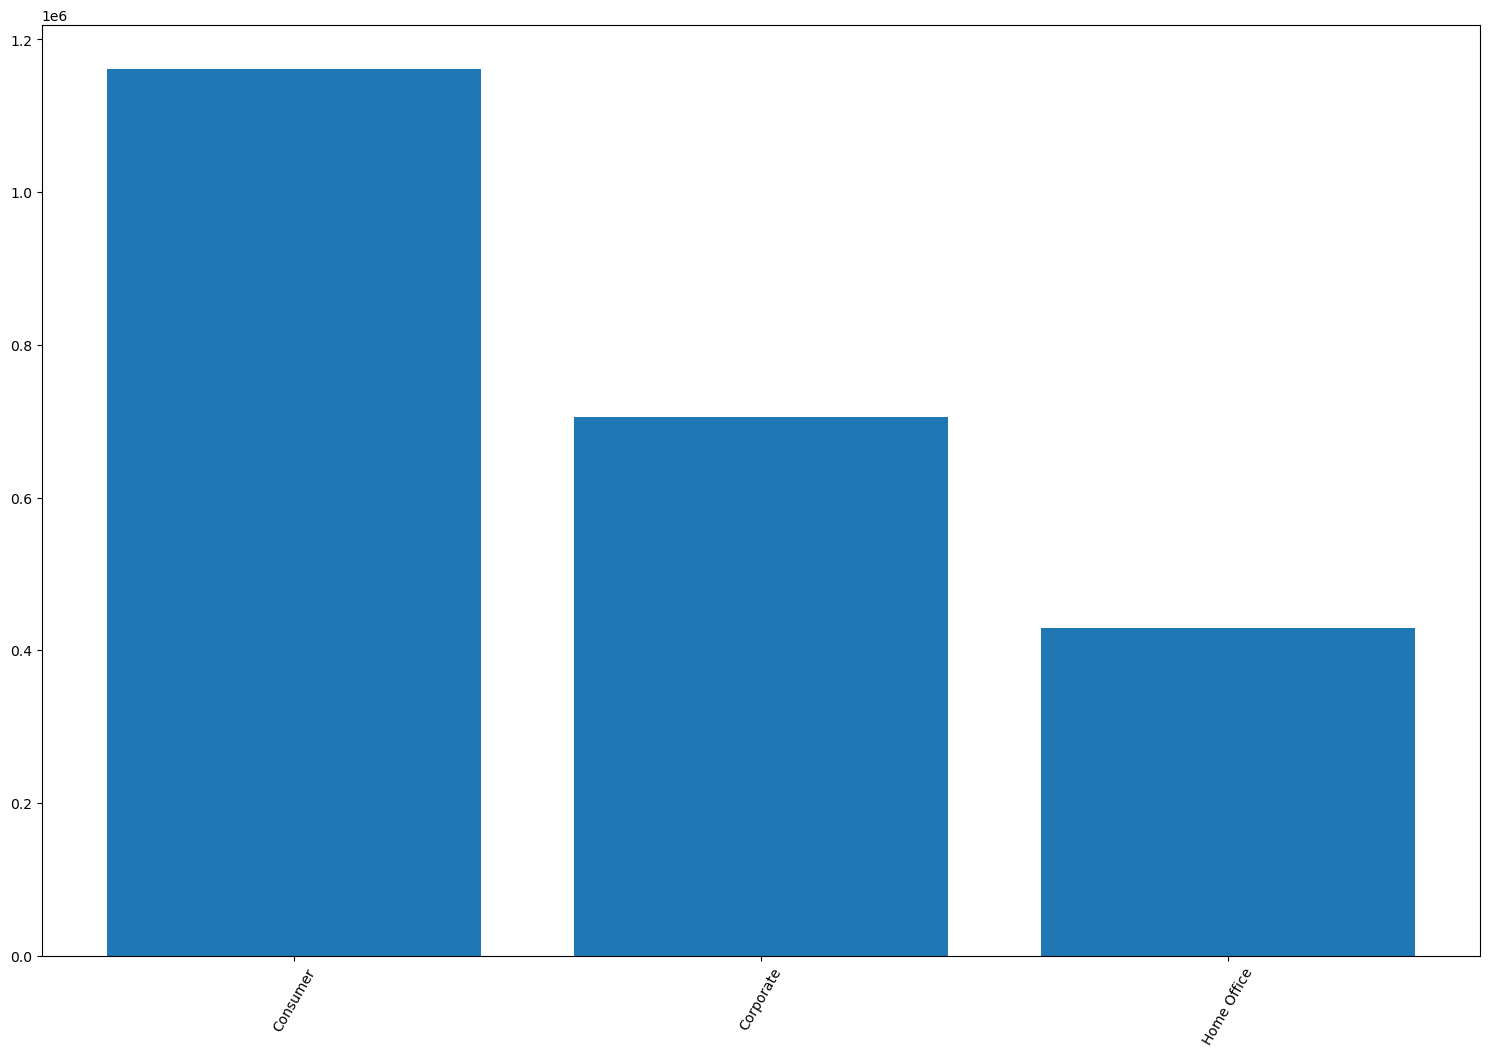

In [230]:

plt.figure(figsize=(15,10))
plt.bar(Segemnt_chart.index,Segemnt_chart['revenue'])
plt.tight_layout()
plt.xticks(rotation=60)
plt.show()

In [202]:

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['year'] = df['Order Date'].dt.year
df['month'] = df['Order Date'].dt.month_name()
df['time'] = df['Order Date'].dt.to_period('M')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,year,month,time
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November,2016-11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November,2016-11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June,2016-06
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October,2015-10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October,2015-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,2014,January,2014-01
9990,9991,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,2017,February,2017-02
9991,9992,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,2017,February,2017-02
9992,9993,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,2017,February,2017-02


In [203]:

montly_sales = df.groupby('time').agg(
     revenue = ('Sales','sum'),
     profit = ('Profit','sum'),
     Transaction = ('Order ID','count')
).sort_index()

montly_sales.sort_values('revenue',ascending=False)




,revenue,profit,Transaction
time,,,
2017-11,118447.8250,9690.1037,459
2016-12,96999.0430,17885.3093,352
2017-09,87866.6520,10991.5556,459
2017-12,83829.3188,8483.3468,462
2014-09,81777.3508,8328.0994,268
2016-11,79411.9658,4011.4075,370
2014-11,78628.7167,9292.1269,318
2017-10,77776.9232,9275.2755,298
2015-11,75972.5635,12474.7884,324


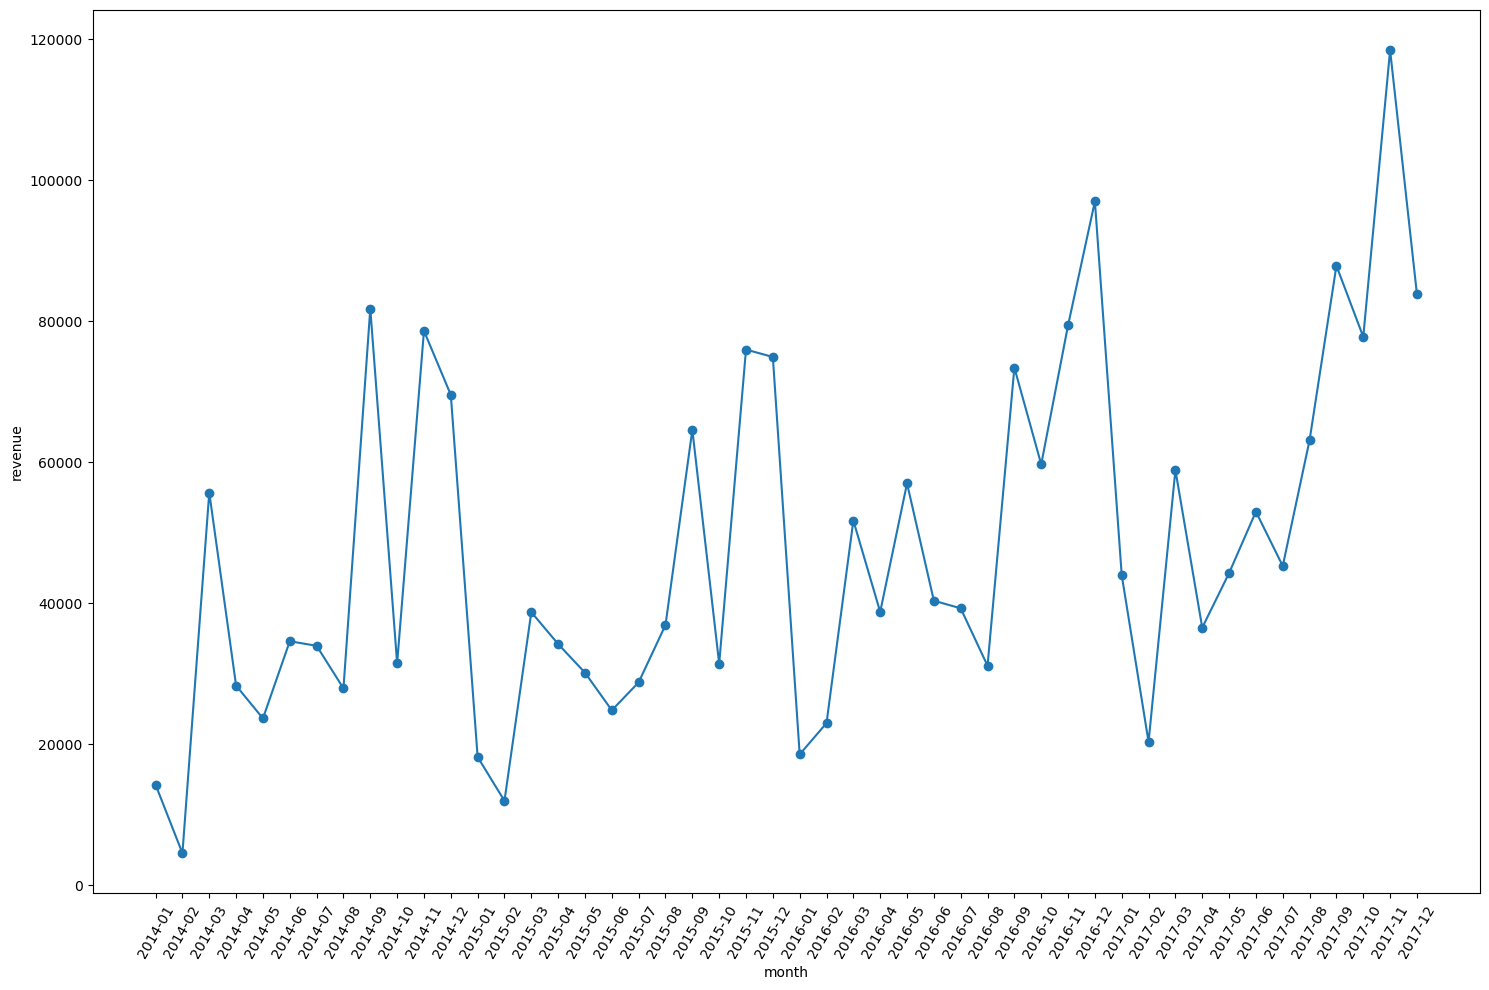

In [205]:

plt.figure(figsize=(15,10))
plt.plot(montly_sales.index.astype(str),montly_sales['revenue'],marker='o')
plt.xlabel('month')
plt.ylabel('revenue')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

In [217]:
customer_sales =  df.groupby('Customer ID').agg(
    order_id = ('Order ID','count'),
    revenue = ('Sales','sum'),
    Quantity = ('Quantity','sum'),
    AOV = ('Sales','mean')
).sort_values('revenue',ascending=False)
display(customer_sales.head(5))
display(customer_sales.tail(5))


,order_id,revenue,Quantity,AOV
Customer ID,,,,
SM-20320,15,25043.050,50,1669.536667
TC-20980,12,19052.218,42,1587.684833
RB-19360,18,15117.339,71,839.852167
TA-21385,10,14595.620,36,1459.562000
AB-10105,20,14473.571,73,723.678550


,order_id,revenue,Quantity,AOV
Customer ID,,,,
RS-19870,3,22.328,10,7.442667
MG-18205,2,16.739,8,8.369500
CJ-11875,1,16.520,5,16.520000
LD-16855,1,5.304,3,5.304000
TS-21085,2,4.833,4,2.416500


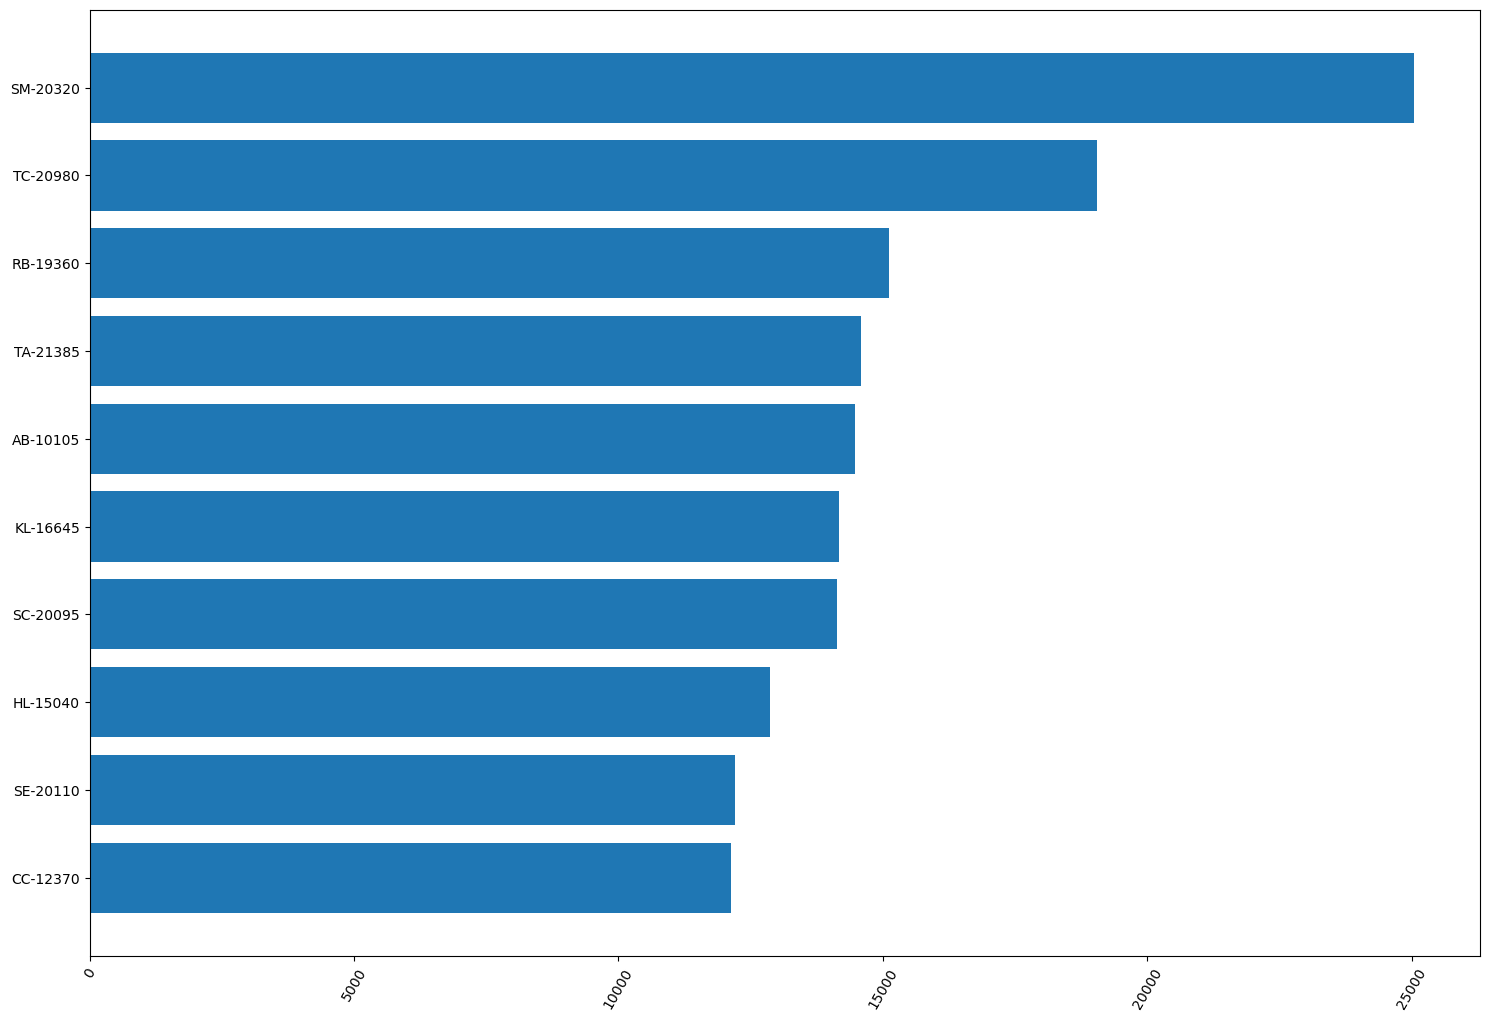

In [228]:
top10 = customer_sales.head(10).sort_values('revenue',ascending=True)
plt.figure(figsize=(15,10))
plt.barh(top10.index,top10['revenue'])
plt.tight_layout()
plt.xticks(rotation=60)
plt.show()